# HealthConnect Clinic


### Project Question: How can HealthConnect Clinic use data and AI to reduce missed appointments and improve the patient support experience

### Week 4 Scope: define the machine learning problem, assess whether the available data can support a no show prediction solution and produce an initial modelling approach. 

# Part 1 - Project & Resource Review
Business Scenario: healthConnect clinic is losing appointment capacity to missed appointments , has difficulty understanding what drives them and wants to use data and AI to improve both attendance and the broader patient support experience

Role of a Data Scientist: define the machine learning problem precisely  - what exactly we are predicting , from what information and for what decision.

Resources Used: 
- HealthConnec_Appointment_Data.csv - 5,000 fictional , anonymized appointment records
- HealthConnect_Data_Dictionary.csv - variable definitions 

# Part 2 - Data Assesment
load & structure

In [1]:
# load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('HealthConnect_Appointment_Data.csv')
print(f"Shape:{df.shape[0]} rows,{df.shape[1]}columns")
df.head()

Shape:5000 rows,18columns


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

# 2.2 Missing Values & Duplicates

In [9]:
missing = df.isnull().sum()
missing_pct = (missing /len(df) * 100).round(2)


appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

In [12]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate appointment_id values: {df['appointment_id'].duplicated().sum()}")



Duplicate rows: 0
Duplicate appointment_id values: 0


In [13]:
# reminder channel is only missing when no reminder was sent - confirmation
print(f"reminder_channel missing vs reminder_sent")
print(pd.crosstab(df['reminder_sent'],df['reminder_channel'].isnull()))

reminder_channel missing vs reminder_sent
reminder_channel  False  True 
reminder_sent                 
No                    0   1366
Yes                3634      0


findng: reminder_chaneel is missing 1,366 rows 
reminder_sent == 'No'
distance _to_clinic_km (90 rows,1.8%) and waiting_time_minutes (60 rows,1,2%) have small ,genuine gaps that will need an imputation decision in the next phase 

before treating a missing value as data quality problem that needs fixing, you need to ask is this missingness random/accidental or is it logically inevitable given what the column means 
a reminder_channle can only exist if a reminder was actually sent

# 2.3 target variable: appointment_outcome

In [15]:
outcome_counts = df['appointment_outcome'].value_counts()
outcome_pct = (df['appointment_outcome'].value_counts(normalize = True)* 100).round(2)
pd.DataFrame({'Count':outcome_counts, 'Percent':outcome_pct})

,Count,Percent
appointment_outcome,,
No-Show,2423,48.46
Attended,2314,46.28
Cancelled,263,5.26


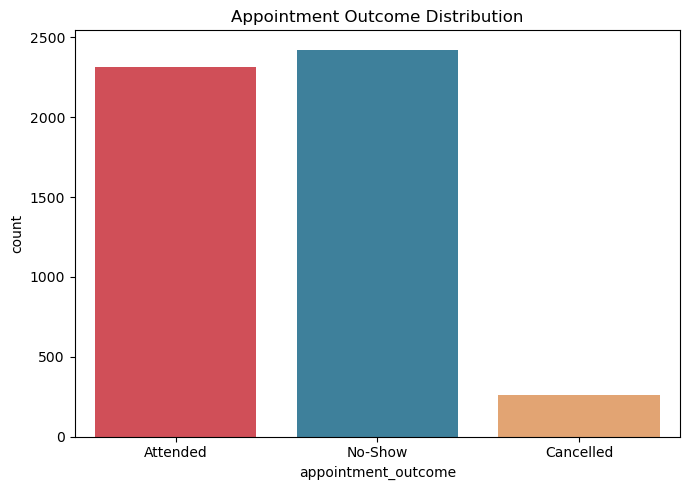

In [18]:
# plot a bar graph of the appointment outcome
fig, ax = plt.subplots(figsize=(7,5))
sns.countplot(data = df, x='appointment_outcome',hue='appointment_outcome',
             order=['Attended','No-Show','Cancelled'],
             palette=['#2E86AB','#E63946','#F4A261'],
             legend=False,ax=ax)
ax.set_title('Appointment Outcome Distribution')
plt.tight_layout()
plt.savefig('appointment_outcome.png',dpi=110)
plt.show()

finding: 48% represents No-Show
        46% representsAttended
        5% represents Cancelled

# 2.4 Data quality - checking whether the DATA matches the way as documented

In [20]:
# check 1: previous_no_shows should never exceed previous_appointments 
violations = (df['previous_no_shows'] > df['previous_appointments']).sum()
violations


0

In [21]:
#check 2: does waiting_time_minutes only exist for patients who actually attended?
# if only existed for 'Attended', that would confirm its an observed , post-visit value

df.groupby('appointment_outcome')['waiting_time_minutes'].agg(['count','mean','min','max'])

,count,mean,min,max
appointment_outcome,,,,
Attended,2293,24.289141,2.0,68.0
Cancelled,261,23.214559,2.0,55.0
No-Show,2386,24.200754,2.0,67.0


finding: waiting_time_minutes has recorded values for No-Show and Cancelled appointments which is kind of impossible for such things to happen. this indicates the field is most likely a pre-appointment estimate. if this interpretation is wrong and the field is in fact a real observed value , it would need to be excluded as target leakage. this is flagged as an asuumption requiring stakeholder confirmation before modelling begins

In [23]:
# ****

# check 3: do previous_appointments / previous_no_shows correlate as genuine running totals
# a true running count could never decrease appointment 

df['appointment_date_dt']= pd.to_datetime(df['appointment_date'],format='%m/%d/%Y',errors='coerce')
df_sorted = df.sort_values(['patient_id','appointment_date_dt']).copy()
df_sorted['prev_appt_diff'] = df_sorted.groupby('patient_id')['previous_appointments'].diff()



In [26]:
non_increasing = (df_sorted['prev_appt_diff'] < 0).sum()
total_pairs = df_sorted['prev_appt_diff'].notna().sum()
print(f"previous_appointments DECREASES from one appointment to the next for the same patient"
   f" in {non_increasing} of {total_pairs} consecutive pairs ({non_increasing/total_pairs*100:.1f}%)")


sample_patient = df[df['patient_id'] =='P-1776'].sort_values('appointment_date_dt')
sample_patient[['patient_id','appointment_date_dt','previous_appointments','previous_no_shows','appointment_outcome']]

previous_appointments DECREASES from one appointment to the next for the same patient in 1397 of 3304 consecutive pairs (42.3%)


,patient_id,appointment_date_dt,previous_appointments,previous_no_shows,appointment_outcome
225,P-1776,2025-06-17,3,0,Attended
3566,P-1776,2025-08-19,4,1,No-Show
2685,P-1776,2025-09-21,2,1,No-Show
4713,P-1776,2025-09-24,4,1,No-Show
4362,P-1776,2025-09-29,5,1,Attended
2725,P-1776,2025-12-04,1,0,Attended
3251,P-1776,2026-02-12,0,0,No-Show
4314,P-1776,2026-02-15,4,0,Attended
649,P-1776,2026-04-09,5,1,No-Show


Findings: previous appointments decreases from one visit to the next in 42.3% of consecutive appointsments by the same patient - this however confirms previous appointments and previous_no_shows are not true as of date running totals within this dataset. this does not disqualify the fields as predicitive features - it means they cannot be trusted or reused as genuine patient history if this project later connects to a real clinic system

In [33]:
# check 4:booking_leads_days should equal appointment_date - booking_date

df['booking_date_dt'] = pd.to_datetime(df['booking_date'],format='%m/%d/%Y',errors='coerce')
computed_lead = (df['appointment_date_dt'] - df['booking_date_dt']).dt.days

mismatches = (computed_lead != df['booking_lead_days']).sum()
print(f"booking_lead_days mismatches vs computed value: {mismatches} of {len(df)} (fully consistent)")
print(f"\npatient_id: {df['patient_id'].nunique()} unique patients across {len(df)} appointments "
      f"(avg {len(df)/df['patient_id'].nunique():.2f} appointments per patient, "
      f"max {df['patient_id'].value_counts().max()})")

booking_lead_days mismatches vs computed value: 0 of 5000 (fully consistent)

patient_id: 1696 unique patients across 5000 appointments (avg 2.95 appointments per patient, max 9)


findings: booking_lead_days is fully internally consistent with 2 date columns  
separetly, patients appear an averge of 3 times each (up to 9 times for one patient) which is important since naively spliting rows at random would let the same patient appear in both the training and test sets.


# Part 3: Machine Learning Problem Definition
problem type: Binary Classification.
Framing: given information available at/before the time an appointment is booked/confirmed , predict whether the patient will fail to attend without cancelling in advance ('a no-show) so that HEalthConnect Clinic can intervene proactively i.e an extra reminder,a confirmation call or deliberate overbooking of high risk slots before appointment date arrives.

why this framing - appointment_outcome has three categories, but they are not symmetric from a business-action standpoint (see Part 4). Restricting the target to a binary Attended vs. No-Show distinction keeps the initial model focused on the specific operational problem named in the business scenario — silent missed appointments — rather than diluting it with a conceptually different outcome (cancellations).

# Part 4: proposed Traget Variable & Handling of Cancellations
proposed target: is_no_show = 1
if appointment_outcome == 'No_show'
else  0,computed only over Attend and No-show records

how cancelled appointments are handled: excluded from the priamary models training data

In [34]:
primary_df = df[df['appointment_outcome'] != 'Cancelled'].copy()
primary_df['is_no_show'] = (primary_df['appointment_outcome'] == 'No-Show').astype(int)

print(f"Records excluded (Cancelled): {(df['appointment_outcome']=='Cancelled').sum()} "
      f"({(df['appointment_outcome']=='Cancelled').mean()*100:.1f}% of full dataset)")
print(f"Remaining records for modelling: {len(primary_df)}")
print(f"\nClass balance in primary_df:")
print(primary_df['is_no_show'].value_counts(normalize=True).round(3))

Records excluded (Cancelled): 263 (5.3% of full dataset)
Remaining records for modelling: 4737

Class balance in primary_df:
is_no_show
1    0.512
0    0.488
Name: proportion, dtype: float64


why we exclude Cancelled:
- a cancellation is know in advance, patient -initiated action
a no-show client is silent,clinic only finds out when the patient fails to arrive
these are different scenarios with different remedies (e.g an easier rescheduling flow may reduce cancellations turning into no-shows )
- cancelled appointment are only 5.3% of the data which is a small group to model reliably as a third class without risking a model that mostly ignores it anyway
- after exclusion the remaining binary problem is close to balanced (51% no-show &49% Attended)

# Part5 -  Potential Input features
eachfield was assesed against the actual no-show rate in the data (not assumed ) and against whether it would realistically be known before the appointment happens

In [35]:
def rate_by(col, bins=None):
    d = primary_df.copy()
    if bins is not None:
        d[col] = pd.cut(d[col], bins=bins)
    return d.groupby(col, observed=True)['is_no_show'].mean().round(3)

print("No-show rate by previous_no_shows:")
print(rate_by('previous_no_shows'))
print("\nNo-show rate by booking_lead_days (bucketed):")
print(rate_by('booking_lead_days', bins=[-1,7,14,30,45,60]))
print("\nNo-show rate by distance_to_clinic_km (bucketed):")
print(rate_by('distance_to_clinic_km', bins=[0,5,10,20,30,50]))

No-show rate by previous_no_shows:
previous_no_shows
0    0.463
1    0.559
2    0.621
3    0.697
4    0.667
5    1.000
Name: is_no_show, dtype: float64

No-show rate by booking_lead_days (bucketed):
booking_lead_days
(-1, 7]     0.295
(7, 14]     0.352
(14, 30]    0.455
(30, 45]    0.570
(45, 60]    0.714
Name: is_no_show, dtype: float64

No-show rate by distance_to_clinic_km (bucketed):
distance_to_clinic_km
(0, 5]      0.487
(5, 10]     0.493
(10, 20]    0.523
(20, 30]    0.584
(30, 50]    0.700
Name: is_no_show, dtype: float64


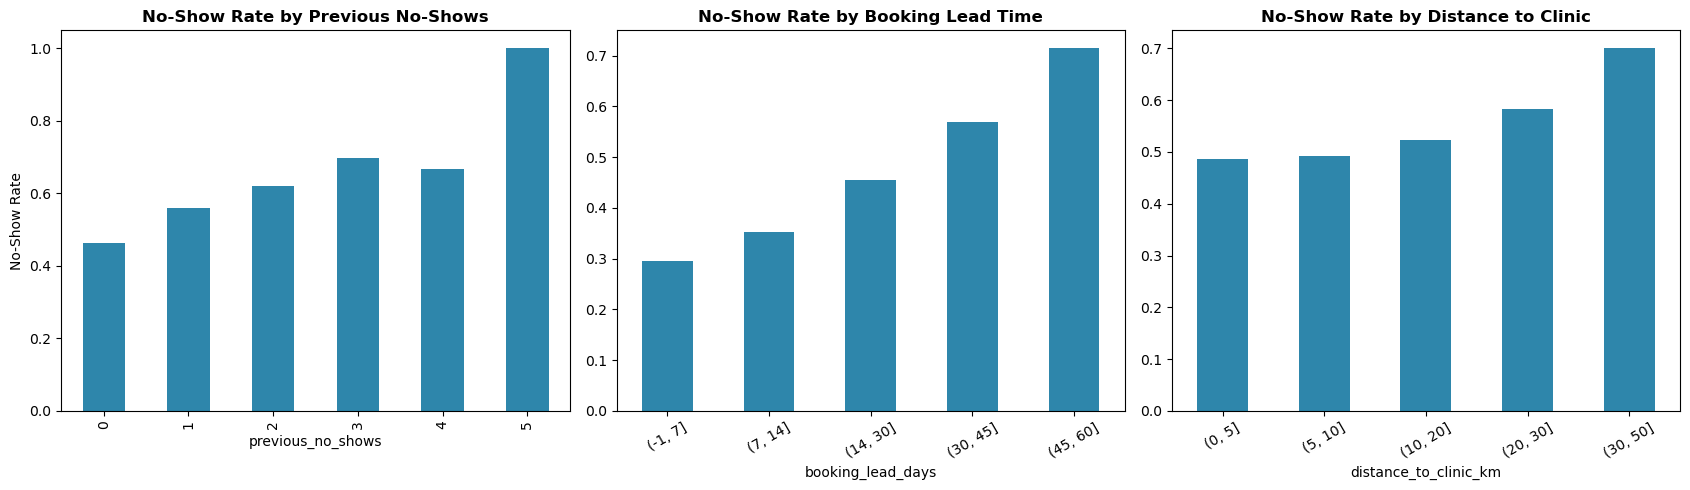

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(17,5))
rate_by('previous_no_shows').plot(kind='bar', ax=axes[0], color='#2E86AB')
axes[0].set_title('No-Show Rate by Previous No-Shows', fontweight='bold'); axes[0].set_ylabel('No-Show Rate')

rate_by('booking_lead_days', bins=[-1,7,14,30,45,60]).plot(kind='bar', ax=axes[1], color='#2E86AB')
axes[1].set_title('No-Show Rate by Booking Lead Time', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

rate_by('distance_to_clinic_km', bins=[0,5,10,20,30,50]).plot(kind='bar', ax=axes[2], color='#2E86AB')
axes[2].set_title('No-Show Rate by Distance to Clinic', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('strong_signal_features.png', dpi=110)
plt.show()

In [38]:
print("No-show rate by reminder_sent:")
print(rate_by('reminder_sent'))
print("\nNo-show rate by age_group:")
print(rate_by('age_group'))
print("\nNo-show rate by appointment_type:")
print(rate_by('appointment_type'))
print("\nNo-show rate by appointment_day:")
print(rate_by('appointment_day'))
print("\nNo-show rate by gender:")
print(rate_by('gender'))

No-show rate by reminder_sent:
reminder_sent
No     0.546
Yes    0.499
Name: is_no_show, dtype: float64

No-show rate by age_group:
age_group
18-24    0.524
25-34    0.529
35-44    0.514
45-54    0.511
55-64    0.530
65+      0.481
Name: is_no_show, dtype: float64

No-show rate by appointment_type:
appointment_type
Diagnostic Test            0.520
Follow-up                  0.542
General Consultation       0.491
Specialist Consultation    0.505
Name: is_no_show, dtype: float64

No-show rate by appointment_day:
appointment_day
Friday       0.487
Monday       0.531
Saturday     0.496
Sunday       0.528
Thursday     0.520
Tuesday      0.489
Wednesday    0.528
Name: is_no_show, dtype: float64

No-show rate by gender:
gender
Female               0.511
Male                 0.515
Prefer not to say    0.448
Name: is_no_show, dtype: float64


# Part 6: Initial Model Approach
problem type: Binary Classification(is_no_show)

train/test split strategy: must be grouped by patient_id, with 1,696 unique patients averaging 3 appointments each, a random split would verly likely place different appointments from the same patient into both the training and tests sets,

Potential baseline models:
Logisitic regression: important in a healthcare operations context where clinic staff will want to understand why a patient is flagged, not just recieve a score

random forest/gradient boosting: to check whether the threshold like patterns observed above in part 5 are captured meaningfully better by a non-linear model than by logistic regression's linear decision boundary.

proposed evaluation metrics: recall and precison on the N-show class , plus ROC-AUC, since a missed true no show(wasted appointment slot) and a false alarm (an unnecessary reminder/overbooking action) carry different operational costs that the clinic should weigh in, not something to assume equally costly by default. the exact cost trade off is a business decision.

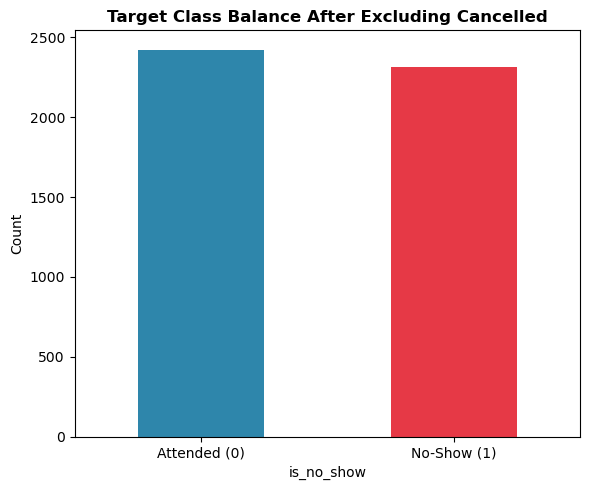

Majority-class baseline accuracy: 51.2%


In [40]:
fig, ax = plt.subplots(figsize=(6,5))
primary_df['is_no_show'].value_counts().plot(kind='bar', color=['#2E86AB','#E63946'], ax=ax)
ax.set_xticklabels(['Attended (0)', 'No-Show (1)'], rotation=0)
ax.set_title('Target Class Balance After Excluding Cancelled', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('target_balance.png', dpi=110)
plt.show()
print(f"Majority-class baseline accuracy: {primary_df['is_no_show'].value_counts(normalize=True).max()*100:.1f}%")

# Part 7 - key Modelling Considerations,Assumptions Limitations & Risks

- waiting_time_minutes - leakage risks: treated as potentially usuable only if confirmed to be a pre appointment estimate rather than a post visit observed value, excluded from the v1 feature set until this is confirmed with stakeholders
- previous_appointments/previous_no_shows are not genuine running totals - these fielsd should be treated as synthetic proxies for this fictional exercise ,not as template for how a real HealthConnect system would compute patient history. if real appointment logs become availabel in a later stage these fields should be rebuilt
- repeated patients require group-aware-spliting - addressed in part6 ,flagged here as a risk if a future contributor rebuilds the split without preserving this constraint.
- small missingness in distance_to_clini_km (1.8%) & witing_time_minute (1.2%) - minor but an imputation strategy (median,mean) should be put into place before model training
- entirely fictional data - the strong patterns found (eig distance and lead time effects on no-show rate) are relationships built into synthetic data generator,not validated real- world clinic behaviour
- ethical consideration: gender & age before any real deployment the model should be checked for materially different error rates across these groups and neither attribute should become a defacto justification for treating patients differently
  

# Part 8: Project Summary
1. problem addressed: defining the machine learning problem for predicting patient no-shows at HealthConnect Clinic and assesing whether the provided dataset can support it.
2. resources used: HealthConnect_Appointment_Data.csv
3. key observation:
   - The data supports a binary classification framing (No-Show vs. Attended), with   Cancelled (5.3%) appropriately excluded from the primary target.
   - Three features show clear, strong signal even before any modelling: previous_no_shows, booking_lead_days, and distance_to_clinic_km.
   - Two real data-quality issues were found that materially affect the modelling plan: previous_appointments/previous_no_shows are not genuine chronological running totals, and waiting_time_minutes has an unresolved leakage risk pending stakeholder confirmation.
   - Patients appear an average of ~3 times each, requiring a patient-grouped train/test split rather than a naive random row split.

4. proposed approach :binary classification of is_no_show, using patient-grouped train/test splitting, starting with Logistic Regression as an interpretable baseline compared against a tree-based ensemble, evaluated on recall/precision/ROC-AUC rather than accuracy alone.
5.  Key considerations affecting the project: the waiting_time_minutes leakage question, the synthetic (non-chronological) nature of the history fields, and the fully synthetic dataset overall — all detailed in Part 7.

6. Proposed focus for Week 5: resolve the waiting_time_minutes question with stakeholders; decide the imputation approach for the two small-missingness numeric fields; carry out fuller bivariate/multivariate statistical validation of the candidate features (similar in rigor to the Week 2-3 heart disease project); and build the first baseline models against the plan defined here.

